# DataLoader

> Build fastai DataLoaders from soil spectra


In [1]:
#| default_exp dataloader

In [2]:
#| export
import numpy as np, torch
from fastcore.all import *
import matplotlib.pyplot as plt
from fastai.torch_core import TensorBase
from fastai.data.block import DataBlock, TransformBlock, RegressionBlock
from kennard_stone import train_test_split as ks_split
from plum import dispatch

import logging
logging.getLogger('kennard_stone').setLevel(logging.WARNING)


In [3]:
from soilspecdl.datasets import load_toy_kssl

The examples use the toy dataset from `soilspecdl.datasets`: 500 KSSL MIR spectra, here with their exchangeable potassium (Kex) values:


In [4]:
toy = load_toy_kssl()
X, y, ids = toy.xy('k.ext_usda.a725_cmolc.kg')
y, wns = y.flatten(), toy.wavenumbers
X.shape, y.shape, wns[[0, -1]]


((500, 1701), (500,), array([ 600, 4000]))

## Splitters

A splitter takes the spectra `X` and the targets `y`, and returns train, validation and test indices. `get_ks_splitter` uses the Kennard-Stone algorithm, which selects samples by their distances in spectral space:

In [5]:
#| export
def get_ks_splitter(
    test_size=0.1, # Proportion of data to hold out for testing
    valid_size=0.1, # Proportion of remaining data after test holdout for validation
)->callable: # Function splitting (X,y) into train/valid/test idxs
    "Create a Kennard-Stone splitter returning train, validation and test indices"
    def _inner(X, y):
        train_val_X, test_X, train_val_idx, test_idx = ks_split(X, np.arange(len(X)), test_size=test_size)
        _, _, train_idx, valid_idx = ks_split(train_val_X, train_val_idx, test_size=valid_size / (1 - test_size))
        return train_idx, valid_idx, test_idx
    return _inner

In [6]:
train_idx, valid_idx, test_idx = get_ks_splitter()(X, y)
test_eq(len(train_idx) + len(valid_idx) + len(test_idx), len(X))
len(train_idx), len(valid_idx), len(test_idx)


(400, 50, 50)

`get_splitter` shuffles the samples with a fixed seed, then cuts them into train, validation and test sets. The test set takes the samples that train and validation leave:

In [7]:
#| export
def get_splitter(
    train_pct=0.8, # Proportion of data for training
    valid_pct=0.1, # Proportion of data for validation
    seed=42, # Random seed for reproducibility
)->callable: # Function splitting (X,y) into train/valid/test idxs
    "Create a random splitter returning train, validation and test indices"
    if train_pct + valid_pct > 1: raise ValueError("train_pct + valid_pct must not exceed 1")
    def _inner(X, y):
        n = len(X)
        np.random.seed(seed)
        shuffled_idx = np.random.permutation(n)
        train_size = int(train_pct * n)
        valid_size = int(valid_pct * n)
        train_idx = shuffled_idx[:train_size]
        valid_idx = shuffled_idx[train_size:train_size + valid_size]
        test_idx = shuffled_idx[train_size + valid_size:]
        return train_idx, valid_idx, test_idx
    return _inner

In [8]:
train_idx, valid_idx, test_idx = get_splitter()(X, y)
test_eq((len(train_idx), len(valid_idx), len(test_idx)), (400, 50, 50))
len(train_idx), len(valid_idx), len(test_idx)


(400, 50, 50)

Proportions whose sum exceeds 1 leave no valid test set, so `get_splitter` raises a `ValueError` as soon as it is created:

In [9]:
expect_fail(lambda: get_splitter(train_pct=0.8, valid_pct=0.5), contains='must not exceed 1')

In [10]:
#| export
def get_pre_splitter(
    n_train, # Number of rows in the existing training set
    valid_pct=0.2, # Proportion of training samples for validation
    seed=42 # Random seed for reproducibility
)->callable: # Function splitting (X,y) into train/valid/test idxs
    "Create a splitter for data whose first `n_train` rows form the training set"
    def _inner(X, y):
        n = len(X)
        train_idx = np.arange(n_train)
        test_idx = np.arange(n_train, n)
        valid_size = int(n_train * valid_pct)
        np.random.seed(seed)
        shuffled = np.random.permutation(train_idx)
        return shuffled[valid_size:], shuffled[:valid_size], test_idx
    return _inner

`get_pre_splitter` suits datasets that come already split into train and test sets. Put the training rows first: the first `n_train` rows become train and validation, and the rest become the test set. With 100 samples and `n_train=80`, 20% of the training rows go to validation:

In [11]:
train_idx, valid_idx, test_idx = get_pre_splitter(n_train=80)(np.zeros((100, 5)), np.zeros(100))
test_eq(test_idx, np.arange(80, 100))
len(train_idx), len(valid_idx), len(test_idx)

(64, 16, 20)

## Data loader

`TensorSpectrum` holds spectra as a fastai tensor. `show` plots a spectrum against its wavenumbers, with the wavenumber axis decreasing from left to right, as is usual for infrared spectra:

In [12]:
#| export
class TensorSpectrum(TensorBase):
    "Spectra tensor that plots each spectrum against its wavenumbers in `wns`"
    def show(self, ctx=None, title=None, figsize=None, **kwargs):
        if ctx is None: _, ctx = plt.subplots(figsize=figsize)
        wns = getattr(self, 'wns', None)
        ctx.plot(range(self.shape[-1]) if wns is None else wns, self.squeeze().cpu(), **kwargs)
        ctx.invert_xaxis()
        ctx.grid(True)
        if title is not None: ctx.set_title(f"Target value: {float(title):.3f}")
        return ctx
    def __repr__(self): return f"TensorSpectrum(shape={tuple(self.shape)})"

In [13]:
TensorSpectrum(X[0], wns=wns)


/Users/franckalbinet/pro/dev/soilspecdl/.venv/lib/python3.12/site-packages/fastai/torch_core.py:140: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  t = torch.as_tensor(x, **kwargs)


TensorSpectrum(shape=(1701,))

Each spectrum stores its own wavenumbers in `wns`. Spectra on different grids can therefore coexist in one session. This example creates an OSSL spectrum (600–4000 cm⁻¹, step 2) and a Fukushima spectrum (685–3965 cm⁻¹, step 5). Tensor operations, batching and indexing keep `wns`:


In [14]:
ossl_spc = TensorSpectrum(torch.randn(1, 1701), wns=np.arange(600, 4001, 2))
fuku_spc = TensorSpectrum(torch.randn(1, 657), wns=np.arange(685, 3966, 5))
scaled = ossl_spc * 2
test_eq(scaled.wns, ossl_spc.wns)
test_eq(len(fuku_spc.wns), 657)
scaled.wns[[0, -1]], fuku_spc.wns[[0, -1]]

(array([ 600, 4000]), array([ 685, 3965]))

`show_batch` plots a batch of spectra in a grid, with each sample's target as its title. fastai calls it from `dls.show_batch`:

In [15]:
#| export
@dispatch
def show_batch(
    x:TensorSpectrum, # Spectra (features)
    y, # Soil property (target)
    samples, # Decoded (spectrum, target) pairs
    ctxs=None, # Unused: `show_batch` creates its own axes
    max_n=9, # Maximum number of spectra to plot
    ncols=3, # Number of columns in the grid
    figsize=None, # Figure size, by default 6 by 3 inches per plot
    **kwargs # Passed to `TensorSpectrum.show`
):
    "Plot a batch of spectra in a grid, titled with their targets"
    n = min(len(samples), max_n)
    ncols = min(ncols, n)
    nrows = (n + ncols - 1) // ncols
    if figsize is None: figsize = (6*ncols, 3*nrows)
    _, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = np.array(axs).flatten()
    for s, ax in zip(samples[:n], axs[:n]): s[0].show(ctx=ax, title=s[1], **kwargs)
    for ax in axs[n:]: ax.axis('off')
    plt.tight_layout()

`SpectralBlock` is the fastai block for spectra. It turns each row of the spectra matrix into a `TensorSpectrum` that carries the wavenumbers:

In [16]:
#| export
def SpectralBlock(
    wns, # Wavenumbers, attached to each spectrum as `wns`
):
    "Block turning each spectrum array into a `TensorSpectrum` carrying `wns`"
    def _to_tensor(x:np.ndarray): return TensorSpectrum(torch.tensor(x, dtype=torch.float32).unsqueeze(0), wns=wns)
    return TransformBlock(type_tfms=_to_tensor)

In [17]:
#| export
def get_spectral_dls(
    X, # Spectral data matrix
    y, # Target values
    wns, # Wavenumbers
    splitter=None, # Function returning train/valid/test idxs
    bs=32, # Batch size
    batch_tfms=None, # Batch transforms, e.g. [StandardizeSpectrum()]
)->tuple: # (DataLoaders with the grid in `dls.wns`, test set indices)
    "Create DataLoaders for spectra, with train, validation and test sets"
    wns = np.asarray(wns)
    if len(wns) != X.shape[-1]: raise ValueError(f"`wns` has {len(wns)} values but `X` has {X.shape[-1]} columns")
    if splitter is None: splitter = get_splitter()
    train_idx, valid_idx, test_idx = splitter(X, y)
    items = list(range(len(X)))
    def _ds_splitter(o): return list(train_idx), list(valid_idx)
    def _get_x(i:int): return X[i]
    def _get_y(i:int): return y[i]
    dblock = DataBlock(blocks=(SpectralBlock(wns), RegressionBlock()), splitter=_ds_splitter, get_x=_get_x, get_y=_get_y, batch_tfms=batch_tfms)
    dls = dblock.dataloaders(items, bs=bs)
    dls.wns = wns
    return dls, test_idx

By default, `get_spectral_dls` splits the samples at random with `get_splitter`. `show_batch` plots spectra with their target values as titles:


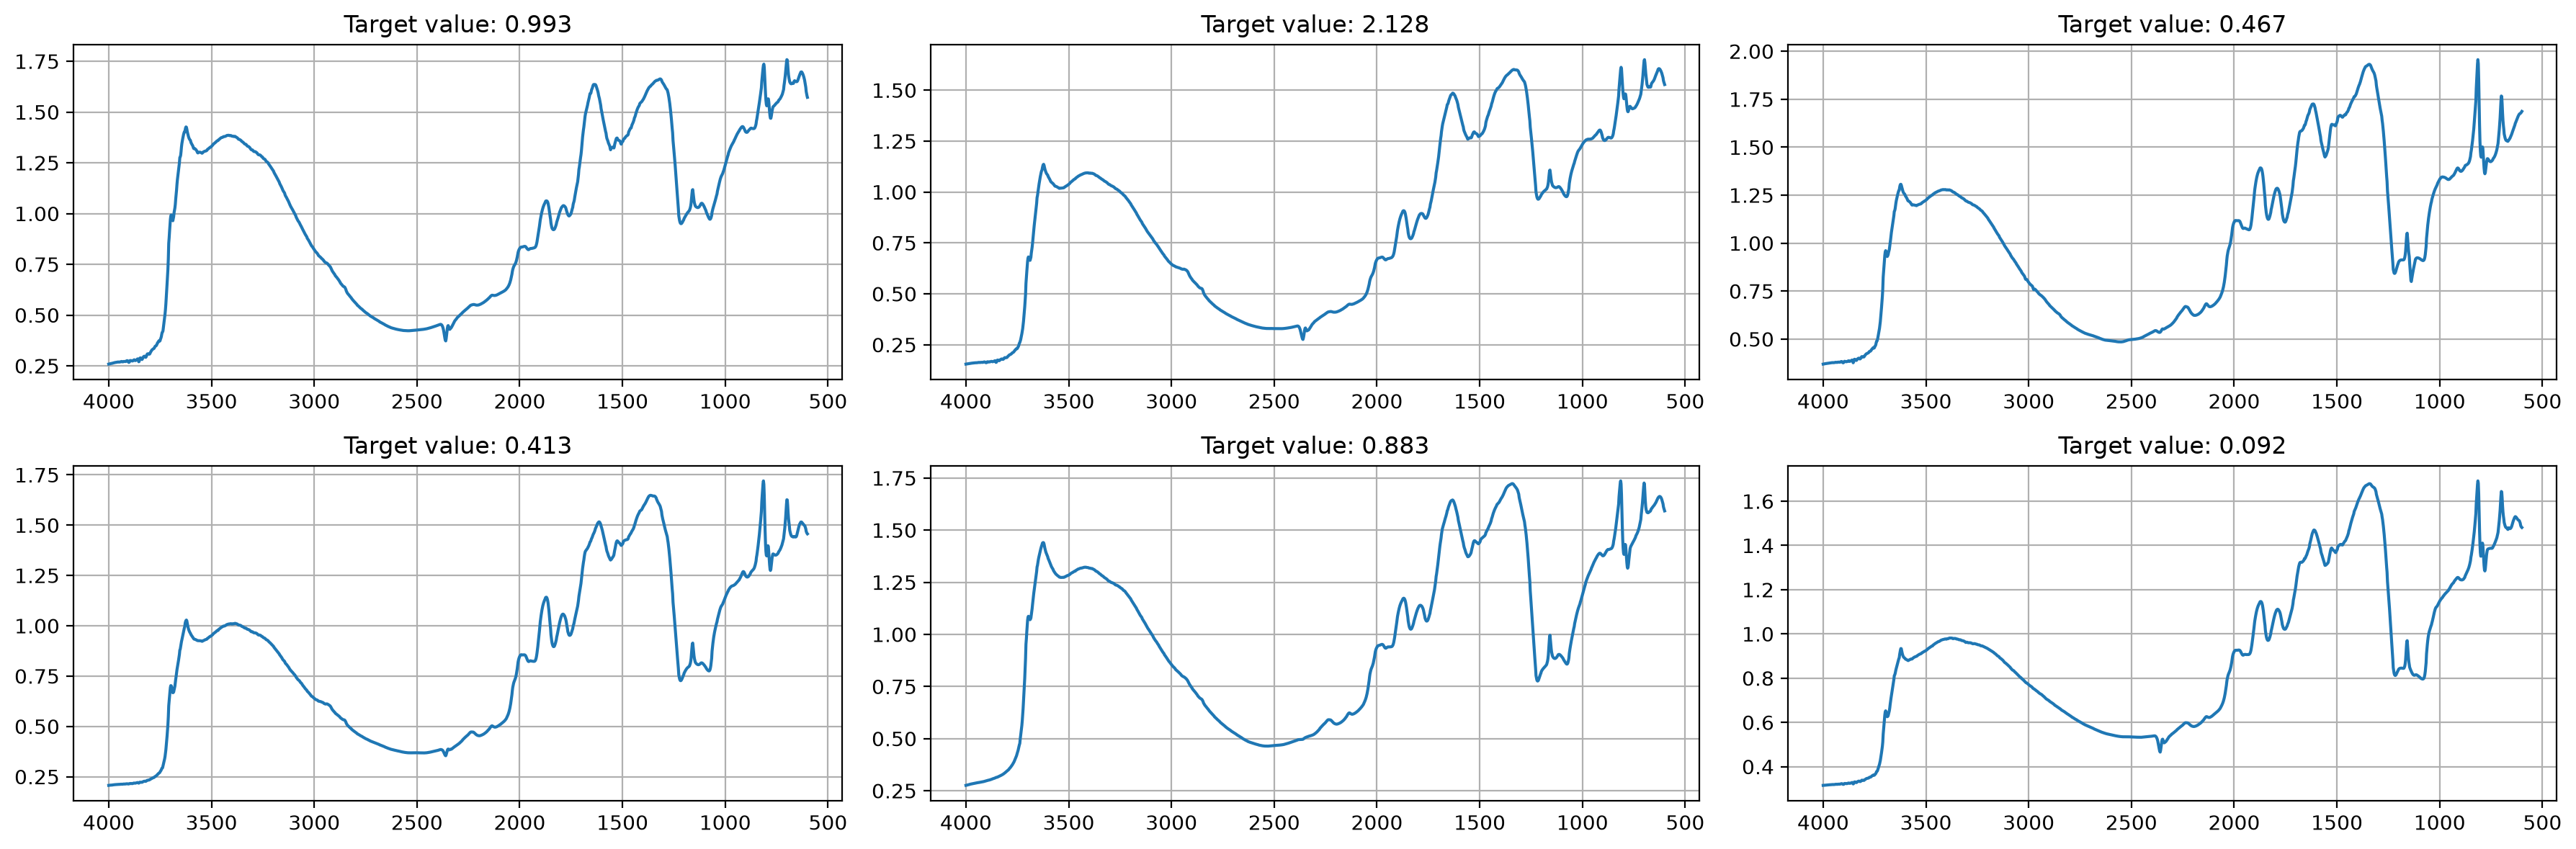

In [18]:
dls, test_idx = get_spectral_dls(X, y, wns)
dls.show_batch(max_n=6, ncols=3)


Pass `splitter` to split another way, for example with Kennard-Stone:

In [19]:
dls_ks, test_idx_ks = get_spectral_dls(X, y, wns, splitter=get_ks_splitter())
len(dls_ks.train_ds), len(dls_ks.valid_ds), len(test_idx_ks)


(400, 50, 50)

`get_spectral_dls` checks that `wns` has one value per column of `X`. A mismatch raises a `ValueError`. Here an OSSL grid of 1,701 wavenumbers is passed with 657-column Fukushima-like spectra:

In [20]:
expect_fail(lambda: get_spectral_dls(np.random.rand(20, 657), np.random.rand(20), np.arange(600, 4001, 2)), contains='`wns` has 1701 values')

The grid is a property of the dataset, so the `DataLoaders` stores it once in `dls.wns`. Code that needs the grid reads it there. Each spectrum also carries a copy, because `show_batch` receives spectra without their `DataLoaders`:

In [21]:
fuku_wns = np.arange(685, 3966, 5)
dls_syn, _ = get_spectral_dls(np.random.rand(100, 657), np.random.rand(100), fuku_wns)
test_eq(dls_syn.wns, fuku_wns)
test_eq(dls_syn.one_batch()[0].wns, dls_syn.wns)
dls_syn.wns[[0, -1]]

array([ 685, 3965])